# STEP 1: Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# STEP 2: Load Data

In [8]:
df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# STEP 3: Basic Info

In [9]:
print(df.head())
print(df.info())
print(df.describe())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

# STEP 4: Data Cleaning

In [13]:
cols_to_drop = ['Name', 'Ticket', 'Cabin', 'PassengerId']
cols_present = [col for col in cols_to_drop if col in df.columns]

df = df.drop(cols_present, axis=1)

# STEP 5: Encoding 

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# STEP 6: Visualization

Target Distribution

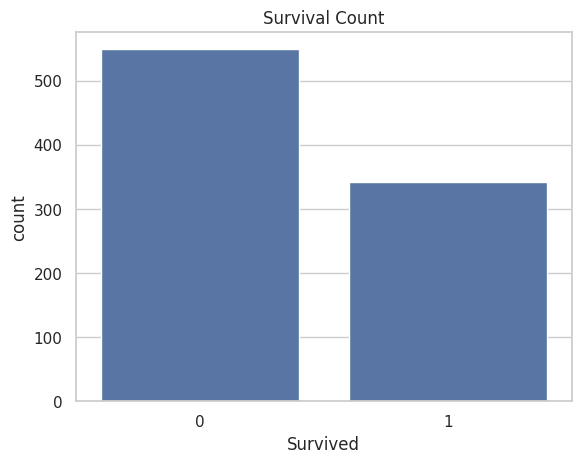

In [15]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

Heatmap

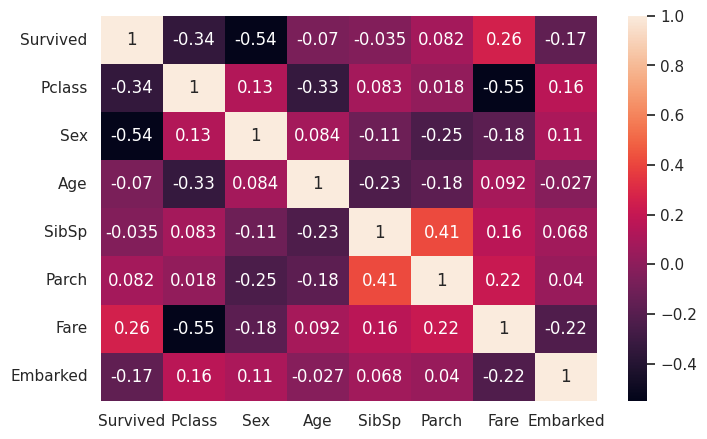

In [16]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True)
plt.show()

Histogram

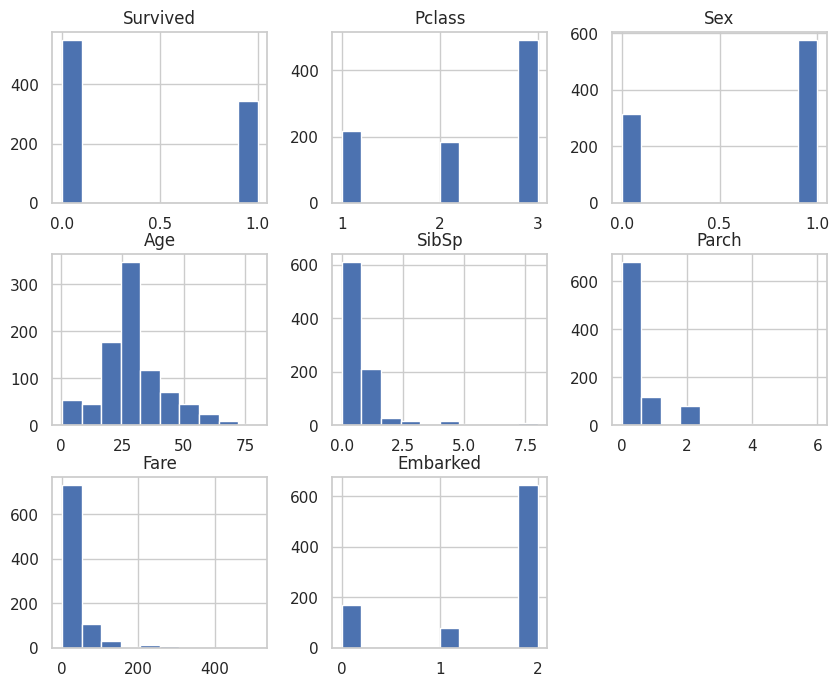

In [17]:
df.hist(figsize=(10,8))
plt.show()

# STEP 7: Feature Selection

In [19]:
X = df.drop('Survived', axis=1)
y = df['Survived']


# STEP 8: Train Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  STEP 9: Naive Bayes Model

In [21]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

# STEP 10: Prediction

In [22]:
y_pred = model.predict(X_test)

# STEP 11: Evaluation

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.776536312849162
[[82 23]
 [17 57]]
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



# STEP 12: GRAPHS

Confusion Matrix

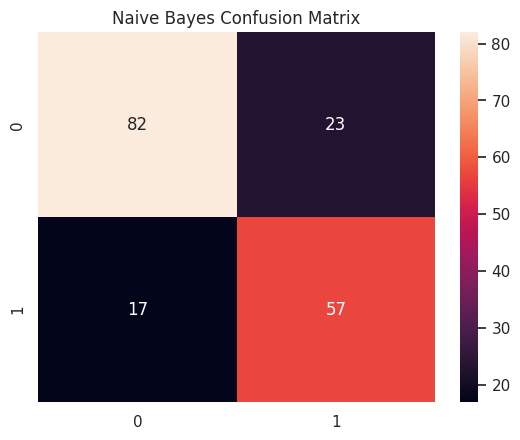

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

Actual vs Predicted

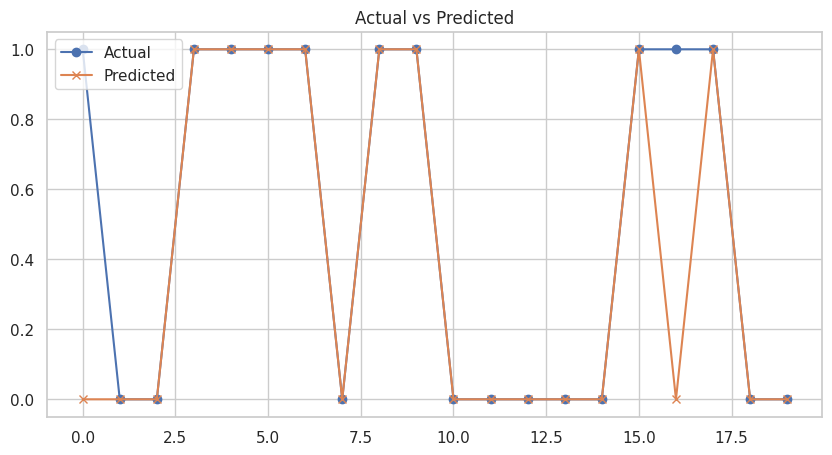

In [25]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:20], label='Actual', marker='o')
plt.plot(y_pred[:20], label='Predicted', marker='x')
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

# STEP 13: Cross Validation

In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross Validation Score:", scores.mean())

Cross Validation Score: 0.7912685958194715
